In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Gathering

In [ ]:
import pandas as pd
path = '/content/drive/MyDrive/Colab Notebooks/Dataset/loan-eligibility/loan-train.csv'
df = pd.read_csv(path)
print("Shape:", df.shape)
print(df.head())

Shape: (614, 13)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2  

# Data Cleaning

## Dropping Unnecessary Columns

In [ ]:
df.drop(columns=["Loan_ID"], inplace=True)


## Handle Missing Values

In [ ]:
print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


### Categorical

In [ ]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

### Numerical

In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


## Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## Feature Engineering

In [ ]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df["LoanAmountPerTerm"] = df["LoanAmount"] / (df["Loan_Amount_Term"] + 1)
df["DebtToIncome"] = df["LoanAmount"] / (df["TotalIncome"] + 1)

In [ ]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanAmountPerTerm,DebtToIncome
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,0.354571,0.021880
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,0.354571,0.021011
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,0.182825,0.021993
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,0.332410,0.024282
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,0.390582,0.023496


# Train Test Split

In [ ]:
X = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"]  # Already encoded: 0 = N, 1 = Y

print("\nClass distribution:")
print(y.value_counts())


Class distribution:
Loan_Status
1    422
0    192
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234, stratify=y
)


# XGBoost Model

In [ ]:
# scale_pos_weight handles class imbalance automatically
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,      # fewer trees
    max_depth=3,           # shallower — prevents memorization
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,         # L1 regularization
    reg_lambda=1.0,        # L2 regularization
    min_child_weight=5,    # require more samples per leaf
    scale_pos_weight=scale,
    eval_metric="logloss",
    random_state=42,
)

In [ ]:
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True,
)

[0]	validation_0-logloss:0.68222
[1]	validation_0-logloss:0.68158
[2]	validation_0-logloss:0.67148
[3]	validation_0-logloss:0.66280
[4]	validation_0-logloss:0.65275
[5]	validation_0-logloss:0.64538
[6]	validation_0-logloss:0.63859
[7]	validation_0-logloss:0.63316
[8]	validation_0-logloss:0.63270
[9]	validation_0-logloss:0.62743
[10]	validation_0-logloss:0.62213
[11]	validation_0-logloss:0.61600
[12]	validation_0-logloss:0.61087
[13]	validation_0-logloss:0.60550
[14]	validation_0-logloss:0.60095
[15]	validation_0-logloss:0.59817
[16]	validation_0-logloss:0.59672
[17]	validation_0-logloss:0.59171
[18]	validation_0-logloss:0.59122
[19]	validation_0-logloss:0.59201
[20]	validation_0-logloss:0.59042
[21]	validation_0-logloss:0.59060
[22]	validation_0-logloss:0.58727
[23]	validation_0-logloss:0.58402
[24]	validation_0-logloss:0.57988
[25]	validation_0-logloss:0.57721
[26]	validation_0-logloss:0.57615
[27]	validation_0-logloss:0.57363
[28]	validation_0-logloss:0.57162
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

# Model Evaluation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
print(f"ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

ROC-AUC: 0.7771 ± 0.0274


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=["Rejected",
                                                          "Approved"]))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


── Classification Report ──
              precision    recall  f1-score   support

    Rejected       0.67      0.47      0.55        38
    Approved       0.79      0.89      0.84        85

    accuracy                           0.76       123
   macro avg       0.73      0.68      0.70       123
weighted avg       0.75      0.76      0.75       123

ROC-AUC Score: 0.7557

Confusion Matrix:
[[18 20]
 [ 9 76]]


# Feature Importance


SHAP plot saved to shap_importance.png


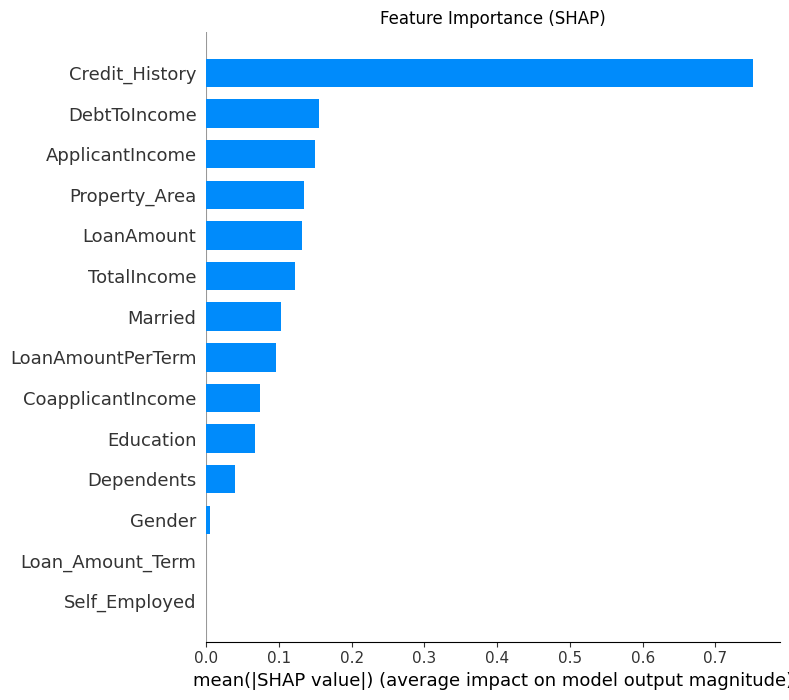

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150)
print("\nSHAP plot saved to shap_importance.png")

# Predict


In [ ]:
# ─────────────────────────────────────────
# 10. PREDICT ON TEST.CSV
# ─────────────────────────────────────────
def predict_from_csv(filepath: str) -> pd.DataFrame:
    test = pd.read_csv(filepath)

    # Save Loan_ID if it exists, then drop it
    loan_ids = test["Loan_ID"] if "Loan_ID" in test.columns else None
    test.drop(columns=["Loan_ID"], errors="ignore", inplace=True)

    # Drop target column if it accidentally exists
    test.drop(columns=["Loan_Status"], errors="ignore", inplace=True)

    # Fill missing values
    for col in test.select_dtypes(include="object").columns:
        test[col].fillna(test[col].mode()[0], inplace=True)
    for col in test.select_dtypes(include=["int64", "float64"]).columns:
        test[col].fillna(test[col].median(), inplace=True)

    # Encode categoricals
    encode_map = {
        "Gender":        {"Male": 1, "Female": 0},
        "Married":       {"Yes": 1, "No": 0},
        "Education":     {"Graduate": 1, "Not Graduate": 0},
        "Self_Employed": {"Yes": 1, "No": 0},
        "Property_Area": {"Urban": 2, "Semiurban": 1, "Rural": 0},
        "Dependents":    {"0": 0, "1": 1, "2": 2, "3+": 3},
    }
    for col, mapping in encode_map.items():
        if col in test.columns:
            test[col] = test[col].map(mapping)

    # Feature engineering (must match training)
    test["TotalIncome"]       = test["ApplicantIncome"] + test["CoapplicantIncome"]
    test["LoanAmountPerTerm"] = test["LoanAmount"] / (test["Loan_Amount_Term"] + 1)
    test["DebtToIncome"]      = test["LoanAmount"] / (test["TotalIncome"] + 1)

    # Predict
    probs  = model.predict_proba(test[X.columns])[:, 1]
    labels = ["Approved ✅" if p >= 0.5 else "Rejected ❌" for p in probs]

    # Build results dataframe
    results = pd.DataFrame({
        "Loan_ID":    loan_ids.values if loan_ids is not None else range(len(test)),
        "Decision":   labels,
        "Confidence": [f"{p:.2%}" for p in probs],
    })

    return results

path = '/content/drive/MyDrive/Colab Notebooks/Dataset/loan-eligibility/loan-test.csv'

# ── Run it ──
results = predict_from_csv(path)
print(results)

# # Optional: save to CSV
# results.to_csv("predictions.csv", index=False)
# print("\nSaved to predictions.csv")

      Loan_ID    Decision Confidence
0    LP001015  Approved ✅     62.60%
1    LP001022  Approved ✅     77.95%
2    LP001031  Approved ✅     61.35%
3    LP001035  Approved ✅     74.16%
4    LP001051  Approved ✅     51.69%
..        ...         ...        ...
362  LP002971  Approved ✅     77.57%
363  LP002975  Approved ✅     71.74%
364  LP002980  Approved ✅     78.68%
365  LP002986  Approved ✅     54.54%
366  LP002989  Approved ✅     50.83%

[367 rows x 3 columns]


/tmp/ipykernel_2261/1578360045.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[col].fillna(test[col].mode()[0], inplace=True)
/tmp/ipykernel_2261/1578360045.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',